# Comprehensive KAN Variants vs MLP Benchmark

**30-seed evaluation of all tuned KAN variants against MLP baseline.**

## KAN Variants Tested:
1. **efficient-kan** (B-splines)
2. **ChebyKAN** (Chebyshev polynomials)
3. **FastKAN** (Radial Basis Functions)
4. **WavKAN** (Mexican Hat Wavelets)
5. **FourierKAN** (Fourier series)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time
import warnings
import os
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score
from scipy import stats

from efficient_kan import KAN
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

np.random.seed(42)
torch.manual_seed(42)
device = torch.device('mps' if torch.backends.mps.is_available() else 'cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")

os.makedirs('../figures', exist_ok=True)

Device: mps


## Load Datasets

In [2]:
# Synthetic Dataset
df_synth = pd.read_excel('../data/High_Accuracy_Sport_Injury_Dataset.xlsx')
X_synth = df_synth.drop('Injury_Risk', axis=1).values
y_synth = df_synth['Injury_Risk'].values
X_synth_scaled = StandardScaler().fit_transform(X_synth)
n_synth = X_synth.shape[1]
print(f"Synthetic: {X_synth.shape[0]} samples, {n_synth} features")

# Real Dataset
df_real = pd.read_csv('../data/player_injuries_impact.csv')
def parse_rating(r):
    try: return float(str(r).replace('(S)', '').strip()) if pd.notna(r) and r != 'N.A.' else np.nan
    except: return np.nan

for i in [1,2,3]:
    df_real[f'rating_before_{i}'] = df_real[f'Match{i}_before_injury_Player_rating'].apply(parse_rating)
    df_real[f'rating_after_{i}'] = df_real[f'Match{i}_after_injury_Player_rating'].apply(parse_rating)

df_real['avg_rating_before'] = df_real[[f'rating_before_{i}' for i in [1,2,3]]].mean(axis=1)
df_real['avg_rating_after'] = df_real[[f'rating_after_{i}' for i in [1,2,3]]].mean(axis=1)
df_real['target'] = (df_real['avg_rating_after'] >= df_real['avg_rating_before']).astype(int)
df_real_clean = df_real.dropna(subset=['target', 'avg_rating_before', 'avg_rating_after']).copy()
df_real_clean['Position_enc'] = LabelEncoder().fit_transform(df_real_clean['Position'])
df_real_clean['Team_enc'] = LabelEncoder().fit_transform(df_real_clean['Team Name'])
df_real_clean['Injury_enc'] = LabelEncoder().fit_transform(df_real_clean['Injury'].str.lower())

X_real = df_real_clean[['Age', 'FIFA rating', 'Position_enc', 'Team_enc', 'Injury_enc', 'avg_rating_before']].values
y_real = df_real_clean['target'].values
X_real_scaled = StandardScaler().fit_transform(X_real)
n_real = X_real.shape[1]
print(f"Real (EPL): {X_real.shape[0]} samples, {n_real} features")

Synthetic: 600 samples, 15 features
Real (EPL): 503 samples, 6 features


## Model Definitions (All Tuned KAN Variants)

In [3]:
# MLP Baseline
class MLP(nn.Module):
    def __init__(self, n, hidden=[64, 32]):
        super().__init__()
        dims = [n] + hidden + [1]
        layers = []
        for i in range(len(dims)-1):
            layers.append(nn.Linear(dims[i], dims[i+1]))
            if i < len(dims)-2:
                layers.extend([nn.BatchNorm1d(dims[i+1]), nn.ReLU(), nn.Dropout(0.2)])
        layers.append(nn.Sigmoid())
        self.net = nn.Sequential(*layers)
    def forward(self, x): return self.net(x)

# efficient-kan (B-spline KAN)
class EfficientKANClassifier(nn.Module):
    def __init__(self, n, hidden=20, grid_size=5):
        super().__init__()
        self.kan = KAN([n, hidden, 1], grid_size=grid_size, spline_order=3)
    def forward(self, x): return torch.sigmoid(self.kan(x))

# ChebyKAN (Chebyshev polynomials)
class ChebyKANLayer(nn.Module):
    def __init__(self, in_f, out_f, degree=4):
        super().__init__()
        self.degree = degree
        self.coeffs = nn.Parameter(torch.randn(in_f, out_f, degree + 1) * 0.1)
        self.bias = nn.Parameter(torch.zeros(out_f))
    def forward(self, x):
        x_n = torch.tanh(x)
        T = [torch.ones_like(x_n), x_n]
        for _ in range(2, self.degree + 1): T.append(2 * x_n * T[-1] - T[-2])
        return torch.einsum('bid,iod->bo', torch.stack(T, dim=-1), self.coeffs) + self.bias

class ChebyKAN(nn.Module):
    def __init__(self, n, hidden=[64, 32], degree=4):
        super().__init__()
        dims = [n] + hidden + [1]
        self.layers = nn.ModuleList([ChebyKANLayer(dims[i], dims[i+1], degree) for i in range(len(dims)-1)])
    def forward(self, x):
        for l in self.layers: x = l(x)
        return torch.sigmoid(x)

# FastKAN (RBF)
class RBFKANLayer(nn.Module):
    def __init__(self, in_f, out_f, num_centers=16):
        super().__init__()
        self.centers = nn.Parameter(torch.linspace(-2, 2, num_centers).unsqueeze(0).unsqueeze(0).repeat(in_f, out_f, 1))
        self.log_bw = nn.Parameter(torch.zeros(in_f, out_f, num_centers))
        self.weights = nn.Parameter(torch.randn(in_f, out_f, num_centers) * 0.1)
        self.bias = nn.Parameter(torch.zeros(out_f))
    def forward(self, x):
        x_exp = x.unsqueeze(2).unsqueeze(3)
        bw = torch.exp(self.log_bw) + 0.1
        rbf = torch.exp(-((x_exp - self.centers) ** 2) / (2 * bw ** 2))
        return (rbf * self.weights).sum(dim=-1).sum(dim=1) + self.bias

class FastKAN(nn.Module):
    def __init__(self, n, hidden=[64, 32], num_centers=16):
        super().__init__()
        dims = [n] + hidden + [1]
        self.layers = nn.ModuleList([RBFKANLayer(dims[i], dims[i+1], num_centers) for i in range(len(dims)-1)])
    def forward(self, x):
        for l in self.layers: x = l(x)
        return torch.sigmoid(x)

# WavKAN (Wavelets)
class WaveletKANLayer(nn.Module):
    def __init__(self, in_f, out_f, num_wavelets=12):
        super().__init__()
        self.trans = nn.Parameter(torch.linspace(-3, 3, num_wavelets).unsqueeze(0).unsqueeze(0).repeat(in_f, out_f, 1))
        self.log_scale = nn.Parameter(torch.zeros(in_f, out_f, num_wavelets))
        self.weights = nn.Parameter(torch.randn(in_f, out_f, num_wavelets) * 0.1)
        self.bias = nn.Parameter(torch.zeros(out_f))
    def mexican_hat(self, x): return (1 - x**2) * torch.exp(-x**2 / 2)
    def forward(self, x):
        x_exp = x.unsqueeze(2).unsqueeze(3)
        scale = torch.exp(self.log_scale) + 0.1
        return (self.mexican_hat((x_exp - self.trans) / scale) * self.weights).sum(dim=-1).sum(dim=1) + self.bias

class WavKAN(nn.Module):
    def __init__(self, n, hidden=[48, 24], num_wavelets=12):
        super().__init__()
        dims = [n] + hidden + [1]
        self.layers = nn.ModuleList([WaveletKANLayer(dims[i], dims[i+1], num_wavelets) for i in range(len(dims)-1)])
    def forward(self, x):
        for l in self.layers: x = l(x)
        return torch.sigmoid(x)

# FourierKAN
class FourierKANLayer(nn.Module):
    def __init__(self, in_f, out_f, grid_size=8):
        super().__init__()
        self.grid_size = grid_size
        self.a = nn.Parameter(torch.randn(in_f, out_f, grid_size) * 0.1)
        self.b = nn.Parameter(torch.randn(in_f, out_f, grid_size) * 0.1)
        self.bias = nn.Parameter(torch.zeros(out_f))
    def forward(self, x):
        freqs = torch.arange(1, self.grid_size + 1, device=x.device).float()
        x_exp = x.unsqueeze(-1)
        cos_t = torch.cos(freqs * x_exp * np.pi)
        sin_t = torch.sin(freqs * x_exp * np.pi)
        return torch.einsum('big,iog->bo', cos_t, self.a) + torch.einsum('big,iog->bo', sin_t, self.b) + self.bias

class FourierKAN(nn.Module):
    def __init__(self, n, hidden=[64, 32], grid_size=8):
        super().__init__()
        dims = [n] + hidden + [1]
        self.layers = nn.ModuleList([FourierKANLayer(dims[i], dims[i+1], grid_size) for i in range(len(dims)-1)])
    def forward(self, x):
        for l in self.layers: x = l(x)
        return torch.sigmoid(x)

In [4]:
def train_model(model, X_train, y_train, epochs=200, lr=0.005):
    model = model.to(device)
    X_t = torch.FloatTensor(X_train)
    y_t = torch.FloatTensor(y_train).unsqueeze(1)
    loader = DataLoader(TensorDataset(X_t, y_t), batch_size=32, shuffle=True)
    opt = optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-4)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(opt, T_max=epochs)
    crit = nn.BCELoss()
    
    for _ in range(epochs):
        model.train()
        for xb, yb in loader:
            xb, yb = xb.to(device), yb.to(device)
            opt.zero_grad()
            crit(model(xb), yb).backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            opt.step()
        scheduler.step()
    return model

def evaluate(model, X_test, y_test):
    model.eval()
    with torch.no_grad():
        y_prob = model(torch.FloatTensor(X_test).to(device)).cpu().numpy().flatten()
    return accuracy_score(y_test, (y_prob > 0.5).astype(int))

## 30-Seed Benchmark

In [5]:
def run_benchmark(X, y, n_features, dataset_name, n_seeds=30):
    print(f"\n{'='*70}")
    print(f"BENCHMARK: {dataset_name} ({n_seeds} seeds)")
    print(f"{'='*70}")
    
    models_config = {
        'MLP': lambda n: MLP(n, [64, 32]),
        'efficient-kan': lambda n: EfficientKANClassifier(n, hidden=20, grid_size=5),
        'ChebyKAN': lambda n: ChebyKAN(n, [64, 32], degree=4),
        'FastKAN': lambda n: FastKAN(n, [64, 32], num_centers=16),
        'WavKAN': lambda n: WavKAN(n, [48, 24], num_wavelets=12),
        'FourierKAN': lambda n: FourierKAN(n, [64, 32], grid_size=8),
    }
    
    results = {name: [] for name in models_config}
    
    for seed in range(1, n_seeds + 1):
        np.random.seed(seed)
        torch.manual_seed(seed)
        X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.2, random_state=seed, stratify=y)
        
        seed_results = {}
        for name, model_fn in models_config.items():
            model = train_model(model_fn(n_features), X_tr, y_tr)
            acc = evaluate(model, X_te, y_te)
            results[name].append(acc)
            seed_results[name] = acc
        
        # Find winner
        best = max(seed_results, key=seed_results.get)
        print(f"Seed {seed:2d}: MLP={seed_results['MLP']:.3f} | eKAN={seed_results['efficient-kan']:.3f} | Cheby={seed_results['ChebyKAN']:.3f} | Fast={seed_results['FastKAN']:.3f} | Wav={seed_results['WavKAN']:.3f} | Four={seed_results['FourierKAN']:.3f} → {best}")
    
    return results

In [6]:
synth_results = run_benchmark(X_synth_scaled, y_synth, n_synth, "Synthetic Sport Injury")


BENCHMARK: Synthetic Sport Injury (30 seeds)


Seed  1: MLP=0.858 | eKAN=0.933 | Cheby=0.900 | Fast=0.942 | Wav=0.900 | Four=0.683 → FastKAN


Seed  2: MLP=0.892 | eKAN=0.883 | Cheby=0.875 | Fast=0.875 | Wav=0.900 | Four=0.683 → WavKAN


Seed  3: MLP=0.833 | eKAN=0.933 | Cheby=0.908 | Fast=0.908 | Wav=0.917 | Four=0.683 → efficient-kan


Seed  4: MLP=0.908 | eKAN=0.908 | Cheby=0.900 | Fast=0.950 | Wav=0.925 | Four=0.692 → FastKAN


...

Seed 26: MLP=0.892 | eKAN=0.958 | Cheby=0.900 | Fast=0.925 | Wav=0.925 | Four=0.683 → efficient-kan


Seed 27: MLP=0.900 | eKAN=0.925 | Cheby=0.900 | Fast=0.925 | Wav=0.950 | Four=0.683 → WavKAN


Seed 28: MLP=0.858 | eKAN=0.925 | Cheby=0.867 | Fast=0.967 | Wav=0.883 | Four=0.683 → FastKAN


Seed 29: MLP=0.867 | eKAN=0.900 | Cheby=0.900 | Fast=0.925 | Wav=0.892 | Four=0.675 → FastKAN


Seed 30: MLP=0.825 | eKAN=0.917 | Cheby=0.867 | Fast=0.933 | Wav=0.892 | Four=0.683 → FastKAN


In [7]:
real_results = run_benchmark(X_real_scaled, y_real, n_real, "Real Premier League")


BENCHMARK: Real Premier League (30 seeds)


Seed  1: MLP=0.663 | eKAN=0.604 | Cheby=0.653 | Fast=0.594 | Wav=0.545 | Four=0.574 → MLP


Seed  2: MLP=0.683 | eKAN=0.673 | Cheby=0.673 | Fast=0.545 | Wav=0.614 | Four=0.446 → MLP


Seed  3: MLP=0.713 | eKAN=0.713 | Cheby=0.713 | Fast=0.505 | Wav=0.703 | Four=0.495 → MLP


Seed  4: MLP=0.594 | eKAN=0.614 | Cheby=0.574 | Fast=0.634 | Wav=0.545 | Four=0.515 → FastKAN


...

Seed 26: MLP=0.713 | eKAN=0.713 | Cheby=0.683 | Fast=0.713 | Wav=0.624 | Four=0.604 → MLP


Seed 27: MLP=0.693 | eKAN=0.713 | Cheby=0.703 | Fast=0.505 | Wav=0.614 | Four=0.495 → efficient-kan


Seed 28: MLP=0.614 | eKAN=0.624 | Cheby=0.584 | Fast=0.614 | Wav=0.535 | Four=0.515 → efficient-kan


Seed 29: MLP=0.713 | eKAN=0.604 | Cheby=0.683 | Fast=0.663 | Wav=0.653 | Four=0.535 → MLP


Seed 30: MLP=0.634 | eKAN=0.624 | Cheby=0.614 | Fast=0.733 | Wav=0.614 | Four=0.505 → FastKAN


## Statistical Analysis

In [8]:
def analyze_results(results, dataset_name):
    print(f"\n{'='*70}")
    print(f"STATISTICAL ANALYSIS: {dataset_name}")
    print(f"{'='*70}")
    
    summary = []
    mlp_accs = np.array(results['MLP'])
    
    for name in results:
        accs = np.array(results[name])
        mean, std = np.mean(accs), np.std(accs)
        ci = stats.t.interval(0.95, len(accs)-1, loc=mean, scale=std/np.sqrt(len(accs)))
        
        # Count wins vs MLP
        if name != 'MLP':
            wins = sum(a > m for a, m in zip(accs, mlp_accs))
            t_stat, p_val = stats.ttest_rel(accs, mlp_accs)
        else:
            wins = '-'
            t_stat, p_val = 0, 1
        
        summary.append({
            'Model': name,
            'Mean': mean,
            'Std': std,
            '95% CI': f"[{ci[0]:.3f}, {ci[1]:.3f}]",
            'Wins vs MLP': wins,
            'p-value': f"{p_val:.4f}" if name != 'MLP' else '-'
        })
    
    df = pd.DataFrame(summary).sort_values('Mean', ascending=False)
    display(df.round(4))
    
    # Best KAN
    kan_models = [k for k in results if k != 'MLP']
    best_kan = max(kan_models, key=lambda k: np.mean(results[k]))
    print(f"\n🏆 Best KAN: {best_kan} ({np.mean(results[best_kan]):.4f})")
    print(f"   MLP baseline: {np.mean(results['MLP']):.4f}")
    
    return df

synth_summary = analyze_results(synth_results, "Synthetic")
real_summary = analyze_results(real_results, "Real (EPL)")


STATISTICAL ANALYSIS: Synthetic


,Model,Mean,Std,95% CI,Wins vs MLP,p-value
1,efficient-kan,0.9242,0.0225,"[0.916, 0.933]",26,0.0000
3,FastKAN,0.9192,0.0228,"[0.911, 0.928]",25,0.0000
4,WavKAN,0.9114,0.0191,"[0.904, 0.919]",27,0.0000
2,ChebyKAN,0.8928,0.0285,"[0.882, 0.903]",21,0.0059
0,MLP,0.8747,0.0348,"[0.862, 0.888]",-,-
5,FourierKAN,0.6836,0.0034,"[0.682, 0.685]",0,0.0000



🏆 Best KAN: efficient-kan (0.9242)
   MLP baseline: 0.8747

STATISTICAL ANALYSIS: Real (EPL)


,Model,Mean,Std,95% CI,Wins vs MLP,p-value
0,MLP,0.6617,0.0457,"[0.645, 0.679]",-,-
2,ChebyKAN,0.6413,0.0599,"[0.619, 0.664]",8,0.0237
1,efficient-kan,0.6383,0.0442,"[0.622, 0.655]",6,0.0058
4,WavKAN,0.6125,0.0421,"[0.597, 0.628]",5,0.0000
3,FastKAN,0.5749,0.0676,"[0.550, 0.600]",2,0.0000
5,FourierKAN,0.5231,0.0534,"[0.503, 0.543]",1,0.0000



🏆 Best KAN: ChebyKAN (0.6413)
   MLP baseline: 0.6617


## Publication Figures

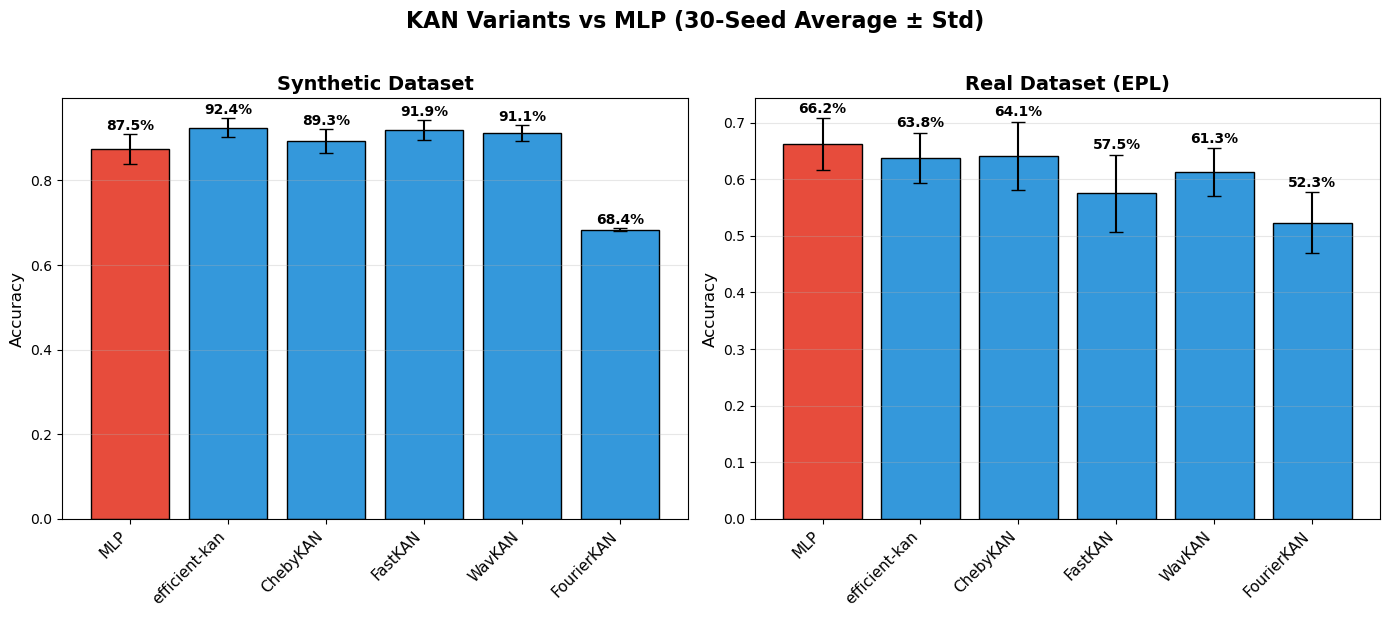

Saved: figures/all_kan_variants_comparison.png


In [9]:
# Figure 1: Main comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

models = ['MLP', 'efficient-kan', 'ChebyKAN', 'FastKAN', 'WavKAN', 'FourierKAN']
colors = ['#e74c3c'] + ['#3498db']*5  # MLP = red, KANs = blue

for ax, results, title in [(axes[0], synth_results, 'Synthetic Dataset'), (axes[1], real_results, 'Real Dataset (EPL)')]:
    means = [np.mean(results[m]) for m in models]
    stds = [np.std(results[m]) for m in models]
    
    bars = ax.bar(range(len(models)), means, yerr=stds, color=colors, capsize=5, edgecolor='black')
    ax.set_xticks(range(len(models)))
    ax.set_xticklabels(models, rotation=45, ha='right', fontsize=11)
    ax.set_ylabel('Accuracy', fontsize=12)
    ax.set_title(title, fontsize=14, fontweight='bold')
    ax.grid(axis='y', alpha=0.3)
    
    for i, (bar, val) in enumerate(zip(bars, means)):
        ax.text(bar.get_x() + bar.get_width()/2, val + stds[i] + 0.01, f'{val:.1%}', 
                ha='center', fontsize=10, fontweight='bold')

plt.suptitle('KAN Variants vs MLP (30-Seed Average ± Std)', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../figures/all_kan_variants_comparison.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.show()
print("Saved: figures/all_kan_variants_comparison.png")

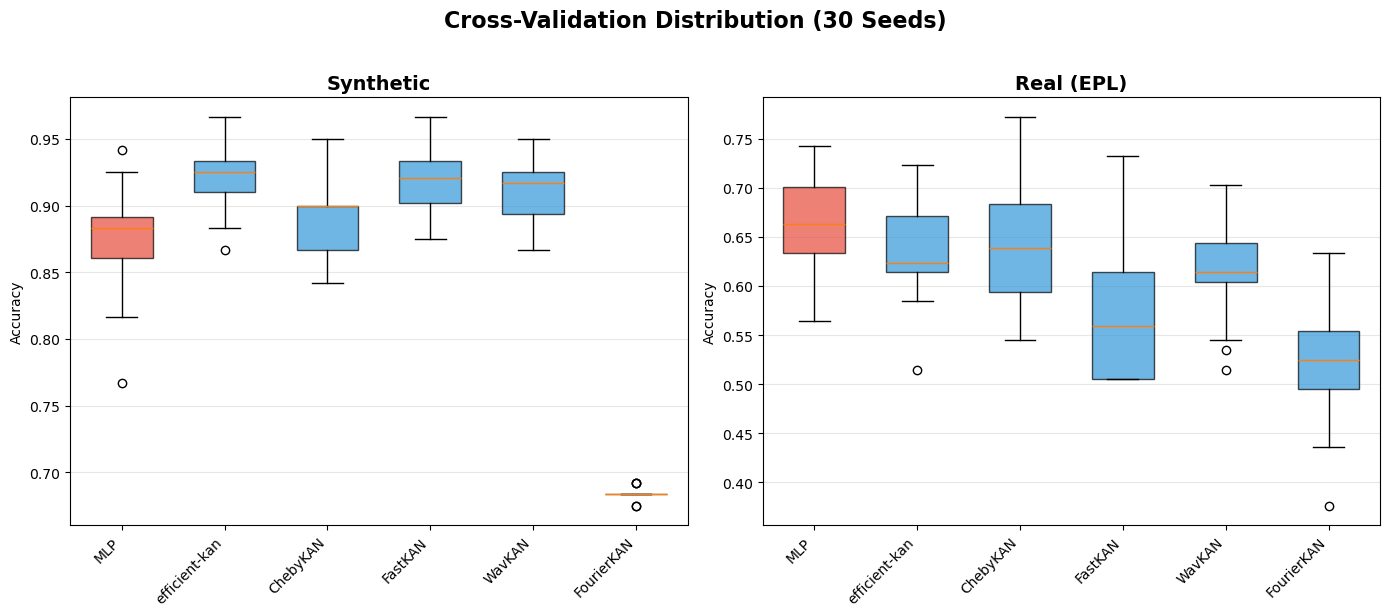

Saved: figures/all_kan_variants_boxplot.png


In [10]:
# Figure 2: Box plots
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax, results, title in [(axes[0], synth_results, 'Synthetic'), (axes[1], real_results, 'Real (EPL)')]:
    data = [results[m] for m in models]
    bp = ax.boxplot(data, labels=models, patch_artist=True, widths=0.6)
    for patch, color in zip(bp['boxes'], colors):
        patch.set_facecolor(color)
        patch.set_alpha(0.7)
    ax.set_xticklabels(models, rotation=45, ha='right')
    ax.set_ylabel('Accuracy')
    ax.set_title(title, fontsize=14, fontweight='bold')
    ax.grid(axis='y', alpha=0.3)

plt.suptitle('Cross-Validation Distribution (30 Seeds)', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../figures/all_kan_variants_boxplot.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.show()
print("Saved: figures/all_kan_variants_boxplot.png")

In [11]:
# Final summary
print("\n" + "="*70)
print("FINAL SUMMARY")
print("="*70)

print("\n📊 SYNTHETIC DATASET:")
for m in models:
    accs = synth_results[m]
    wins = sum(a > synth_results['MLP'][i] for i, a in enumerate(accs)) if m != 'MLP' else '-'
    print(f"   {m:15s}: {np.mean(accs):.4f} ± {np.std(accs):.4f} | Wins vs MLP: {wins}")

print("\n📊 REAL DATASET (EPL):")
for m in models:
    accs = real_results[m]
    wins = sum(a > real_results['MLP'][i] for i, a in enumerate(accs)) if m != 'MLP' else '-'
    print(f"   {m:15s}: {np.mean(accs):.4f} ± {np.std(accs):.4f} | Wins vs MLP: {wins}")


FINAL SUMMARY

📊 SYNTHETIC DATASET:
   MLP            : 0.8747 ± 0.0348 | Wins vs MLP: -
   efficient-kan  : 0.9242 ± 0.0225 | Wins vs MLP: 26
   ChebyKAN       : 0.8928 ± 0.0285 | Wins vs MLP: 21
   FastKAN        : 0.9192 ± 0.0228 | Wins vs MLP: 25
   WavKAN         : 0.9114 ± 0.0191 | Wins vs MLP: 27
   FourierKAN     : 0.6836 ± 0.0034 | Wins vs MLP: 0

📊 REAL DATASET (EPL):
   MLP            : 0.6617 ± 0.0457 | Wins vs MLP: -
   efficient-kan  : 0.6383 ± 0.0442 | Wins vs MLP: 6
   ChebyKAN       : 0.6413 ± 0.0599 | Wins vs MLP: 8
   FastKAN        : 0.5749 ± 0.0676 | Wins vs MLP: 2
   WavKAN         : 0.6125 ± 0.0421 | Wins vs MLP: 5
   FourierKAN     : 0.5231 ± 0.0534 | Wins vs MLP: 1
